# DBSCAN on the Smiling Face

Done


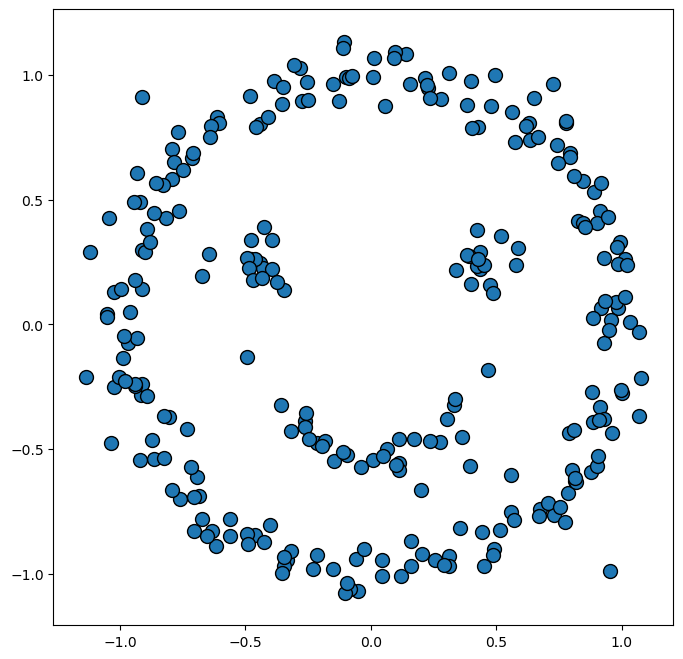

In [1]:
from sklearn.datasets import make_moons
from sklearn.datasets import make_circles
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import mglearn

def createFace():
    X,y = make_circles(n_samples=(200,0), shuffle=True, noise=0.06, random_state=42, factor=0.8)
    # add mouth
    Xm,ym = make_circles(n_samples=(70,0), shuffle=True, noise=0.1, random_state=42, factor=0.8)
    Xm=Xm/3
    indexes=np.where(Xm[:,1]<-0.1)
    Xm=Xm[indexes]
    ym=ym[indexes]
    Xm=Xm-[0,0.2]
    X = np.vstack((X,Xm))
    # add left eye
    Xeye,yeye = make_blobs(n_samples=15, centers=1, n_features=2,cluster_std=0.1, random_state=0)
    Xeye = StandardScaler().fit_transform(Xeye);
    Xeye=Xeye/15
    Xeye=Xeye+(-0.45, 0.25, )
    X = np.vstack((X,Xeye))
    # add right eye
    Xeye2,yeye = make_blobs(n_samples=15, centers=1, n_features=2,cluster_std=0.1, random_state=42)
    Xeye2 = StandardScaler().fit_transform(Xeye2);
    Xeye2=Xeye2/15
    Xeye2=Xeye2+(0.45, 0.25)
    X = np.vstack((X,Xeye2))
    # add noise
    np.random.seed(4)
    noise = np.random.random((16,2))*2-(1,1)
    X = np.vstack((X,noise))
    return X

X = createFace()
plt.figure(figsize=(8,8))
mglearn.discrete_scatter(X[:,0], X[:,1], np.ones(len(X)))
print("Done")

**KMeans with 4 Clusters**

Plotting function defined


C:\Users\herrler\Anaconda3\envs\ML\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


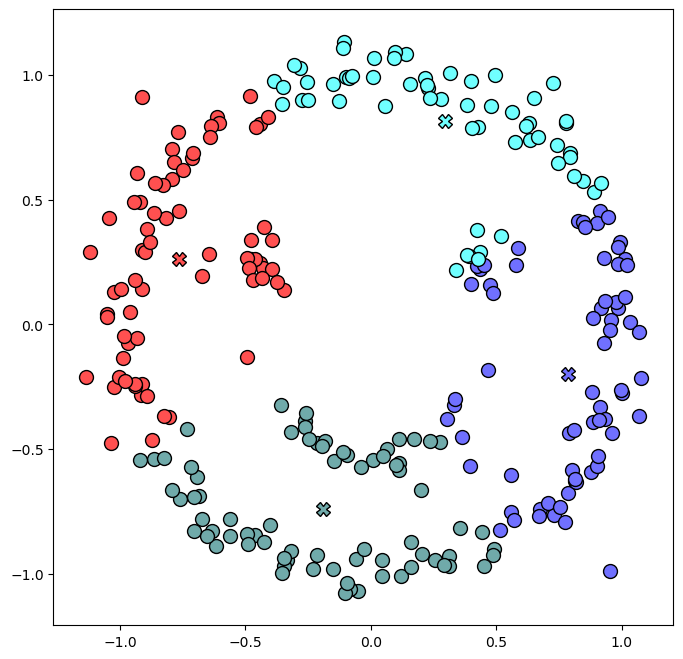

In [2]:
from sklearn.cluster import KMeans

def plotCluster(X, y, centroids):
    """
    Works up to 7 clusters / 7 Colors
    """
    #up to 4 colors stacked 2 times 
    cm_cycle = ['#7070ff', '#ff5050', '#70ffff', '#70aaaa', '#aa5050', '#70aaff', '#70aa70']
    cm_cycle = cm_cycle[:len(np.unique(y))]
    cm_cycle = np.hstack((cm_cycle, cm_cycle))
    
    markers=np.hstack((['o']*len(np.unique(y)),['X']*len(np.unique(y)))) 

    Xplot = np.vstack((X,centroids))
    yplot = np.hstack((y,np.arange(len(centroids))%len(X)+len(X)))

    plt.figure(figsize=(8,8))
    mglearn.discrete_scatter(Xplot[:, 0], Xplot[:, 1], yplot, markers=markers, c=cm_cycle)
print("Plotting function defined")


means=KMeans(n_clusters=4)
y = means.fit_predict(X);
plotCluster(X,y,means.cluster_centers_)


**DBSCAN out of the box**

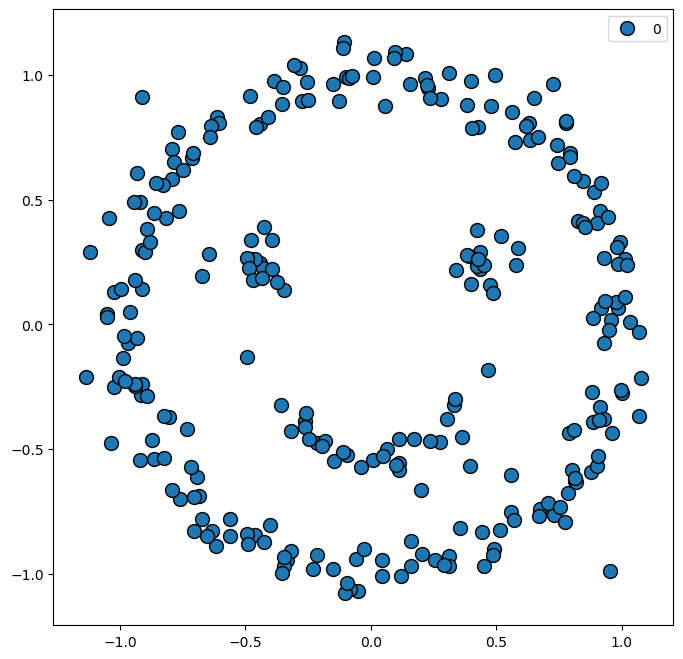

In [3]:
from sklearn.cluster import DBSCAN 

# very sensitive to parametrization
X = createFace()
clustering = DBSCAN().fit(X) # return das DB-SCAN-Object, predict kann nicht mit neuen Daten aufgerufen werden
#y = DBSCAN().fit_predict(X) # alternative way to get the result

plt.figure(figsize=(8,8))
mglearn.discrete_scatter(X[:,0], X[:,1], clustering.labels_)
plt.legend()
#print(clustering.labels_)


In [4]:
print("Radius:", clustering.eps) # eps = epsilon
print("min_samples", clustering.min_samples) 

Radius: 0.5
min_samples 5


**DB Scan Adjusted**

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1

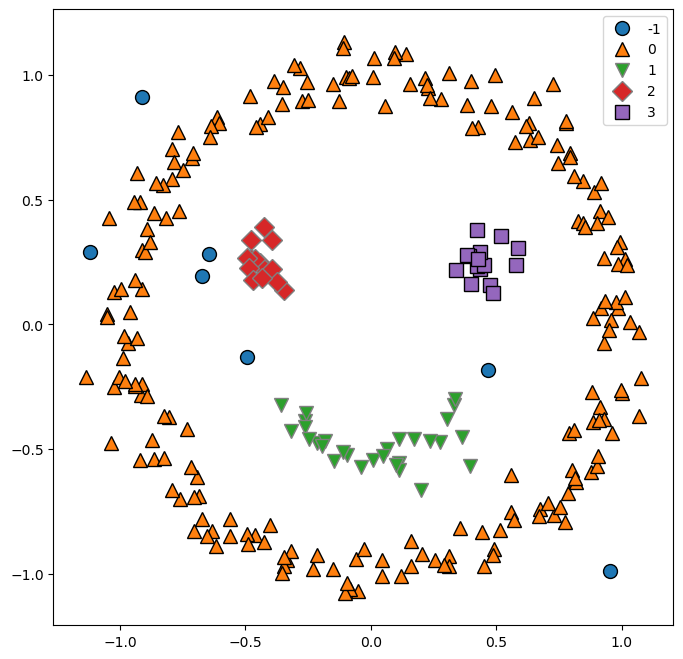

In [5]:
from sklearn.cluster import DBSCAN 

# very sensitive to parametrization
y = DBSCAN(eps=0.15, min_samples=3).fit_predict(X)
#y = DBSCAN(eps=0.2, min_samples=6).fit_predict(X) # alternative

plt.figure(figsize=(8,8))
mglearn.discrete_scatter(X[:,0], X[:,1], y)
plt.legend()
y


**Test of other Methods**

C:\Users\herrler\Anaconda3\envs\ML\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


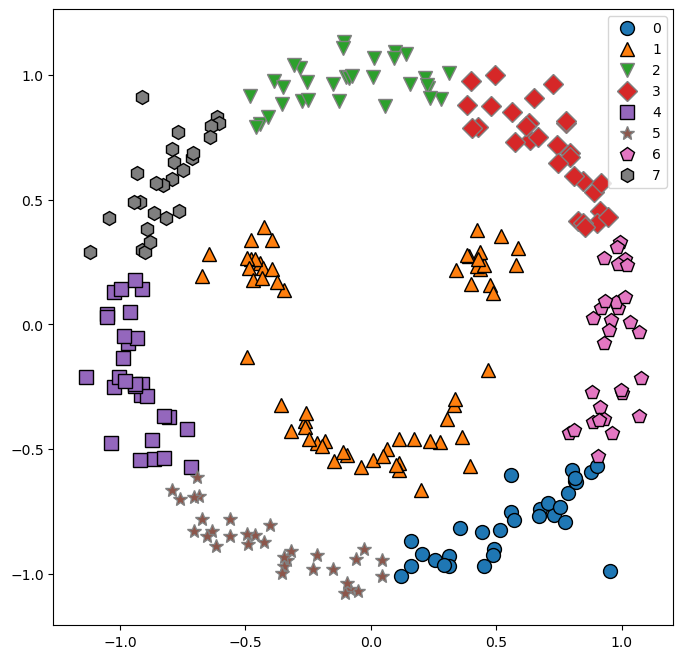

In [6]:
from sklearn.cluster import OPTICS
from sklearn.cluster import SpectralClustering

spectral = SpectralClustering(n_neighbors=4).fit(X)
spectral.labels_
plt.figure(figsize=(8,8))
mglearn.discrete_scatter(X[:,0], X[:,1], spectral.labels_)
plt.legend()

# optics will work with eps=0.15, 
#y = OPTICS(eps=1500).fit_predict(X)
#plt.figure(figsize=(8,8))
#mglearn.discrete_scatter(X[:,0], X[:,1], y)
#plt.legend()
